# Import Setup

In [29]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

___________________________________

# Load the dataset
using pandas as data is a csv

In [30]:
# get the file
df = pd.read_csv(r'C:\Users\jovin\Desktop\TF\MLOPS\EndToEndMLPipeline\data\raw\Bank Customer Churn Prediction.csv')
df.shape, df.columns

((10000, 12),
 Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
        'balance', 'products_number', 'credit_card', 'active_member',
        'estimated_salary', 'churn'],
       dtype='object'))

In [31]:
df.head(5)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [32]:
# check for missing values and outliers
df.describe(include= 'all')

# as seen country and gender are the only categorical values
# and they have 3 and 2 unique values respectively

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.569094e+07,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


________________________________

# one-hot encoding for the unique values
## Gender



In [33]:
df['gender'] = df['gender'].replace({
    'Male': 1, 
    'Female': 0
})

C:\Users\jovin\AppData\Local\Temp\ipykernel_2856\1378422879.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'] = df['gender'].replace({


## Country; one-hot encoding for multiple unique values

In [34]:
df = pd.get_dummies(df, columns = ['country'], drop_first = True) # only need n-1 columns to replresent all possible info
df.head()

,customer_id,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain
0,15634602,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,15647311,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,15619304,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,15701354,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,15737888,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


## Cleaning

In [39]:
# first dropping customer_id, no relation to churn
df = df.drop('customer_id', axis = 1)

In [37]:
# convert the bool values to numerica
# get the bool 
cols = df.select_dtypes(include = 'bool').columns
df[cols] = df[cols].astype(int)

In [40]:
df.head()

,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   credit_score      10000 non-null  int64  
 1   gender            10000 non-null  int64  
 2   age               10000 non-null  int64  
 3   tenure            10000 non-null  int64  
 4   balance           10000 non-null  float64
 5   products_number   10000 non-null  int64  
 6   credit_card       10000 non-null  int64  
 7   active_member     10000 non-null  int64  
 8   estimated_salary  10000 non-null  float64
 9   churn             10000 non-null  int64  
 10  country_Germany   10000 non-null  int64  
 11  country_Spain     10000 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 937.6 KB


______________________________________________________________________________________________
This now completes the preprocessing part. 
As we can see all the data/features ahve been clearned and turned to a numberical value which allows us to now move on to feature engineering
____________________________________

## Heat map: visualize correlation
here it is clear that\
Age, Country_germany and balcance have a positive correlation with churning\
Older the customer/higher balance are less likely to churn\
\
While, Gender and active member have a negative correlation with churning\
Lower active membership time are more likely to churn


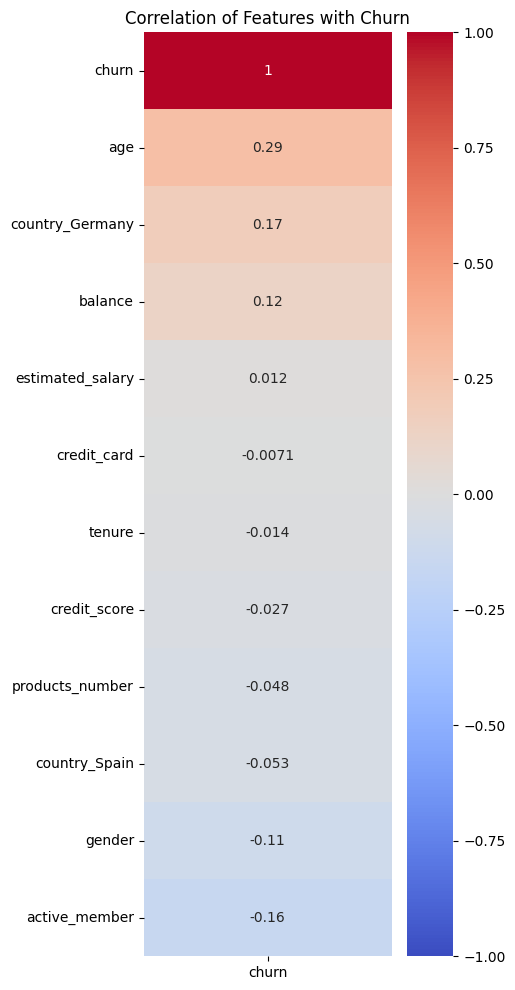

In [46]:
# only fine relationships for numerical values, which is all the values in general
# df.corr only gives a 2x2 matrix, but we need correlation to churn rather than with each other
# first figure out which variables explain the churn better, then later check which of these features explain each other
corr = df.corr(numeric_only = True)

churn_corr = corr[['churn']].sort_values(by = 'churn', ascending = False)

# seaborn heatmap
plt.figure(figsize = (4,12))
sns.heatmap(churn_corr, annot = True, cmap = 'coolwarm', vmin = -1, vmax = 1)
plt.title('Correlation of Features with Churn')
plt.show()

In hind sight there are only 12 features which is not too bad to just simply use them 

_________________________

# Check for class imbalance

In [50]:
df['churn'].value_counts()
# as we see here the data is 80% toward class 0 and 20% toward class 1, 
# So solution, 
#     Eitehr set threhold, 
#     Or, use model that works with class imbalance
#     And split dataset with stratification to mimic the entire dataset

# Keep in mind for the Model selection/processing

churn
0    7963
1    2037
Name: count, dtype: int64

In [52]:
df.to_csv(r'C:\Users\jovin\Desktop\TF\MLOPS\EndToEndMLPipeline\data\processed\ProcessedChurnDS.csv')

______________________________________

# ML Model

Model Creation Done in next notebook